# Bitcoin Market Sentiment vs Trader Performance Analysis

## Objective
Analyze the relationship between Bitcoin Fear & Greed Index sentiment and trader performance using Hyperliquid trading data.

In [1]:
# Import our tools

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [4]:
# Load Data

trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

In [5]:
# Explore Data

trades.head()
trades.info()

sentiment.head()
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [11]:
# check null values

trades.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [33]:
# check null values

sentiment.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [35]:
# Convert dates 

trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
)

trades['date'] = trades['Timestamp IST'].dt.date

In [36]:
# Convert dates 

sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

In [37]:
# Merge

df = pd.merge(
    trades,
    sentiment,
    on='date',
    how='left'
)

In [38]:
# Verify merge

print(df['classification'].value_counts(dropna=False))

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
NaN                  6
Name: count, dtype: int64


In [39]:
df = df.dropna(subset=['classification'])

In [40]:
# Average Profit by Sentiment

profit_by_sentiment = df.groupby('classification')['Closed PnL'].mean()

print(profit_by_sentiment)

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64


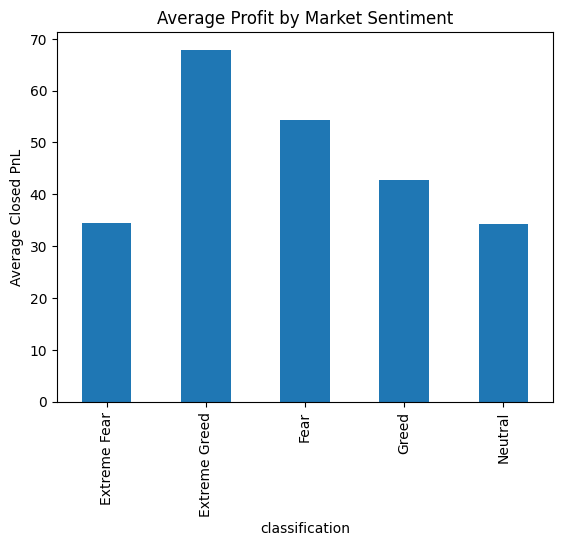

In [59]:
# Chart

import matplotlib.pyplot as plt

profit_by_sentiment.plot(kind='bar')

plt.title("Average Profit by Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.savefig("profit_by_sentiment.png", bbox_inches="tight")
plt.show()

In [42]:
# Trade Count by Sentiment

df['classification'].value_counts()

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

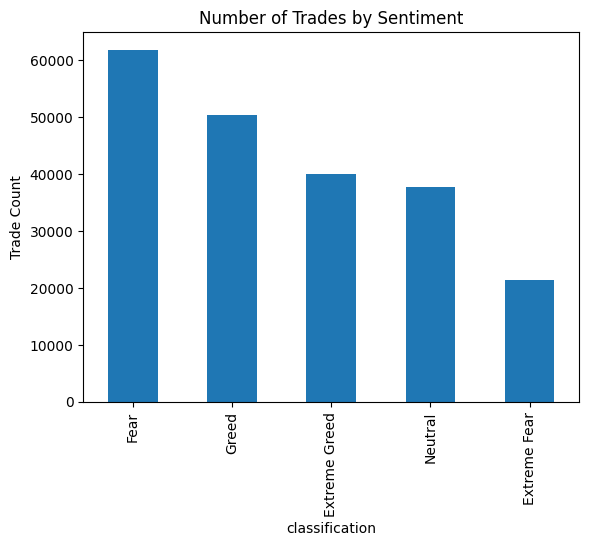

In [61]:
# Chart

df['classification'].value_counts().plot(kind='bar')

plt.title("Number of Trades by Sentiment")
plt.ylabel("Trade Count")
plt.savefig("Number of Trades by Sentiment", bbox_inches="tight")
plt.show()

In [44]:
# Win Rate by Sentiment

df['Win'] = df['Closed PnL'] > 0

In [45]:
# Calculate win rate

win_rate = df.groupby('classification')['Win'].mean() * 100

print(win_rate)

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: Win, dtype: float64


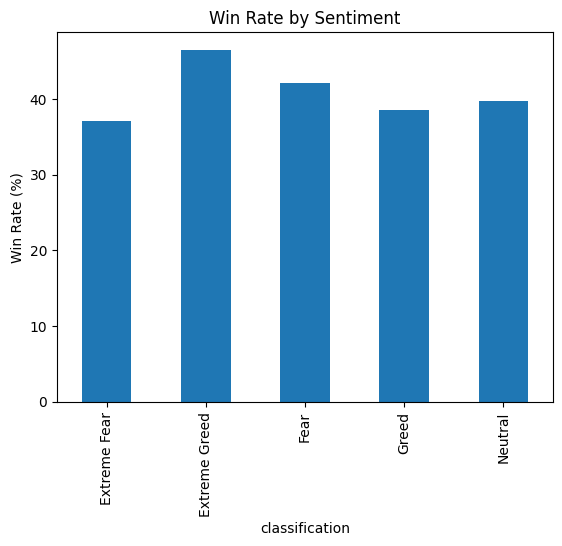

In [62]:
# Chart

win_rate.plot(kind='bar')

plt.title("Win Rate by Sentiment")
plt.ylabel("Win Rate (%)")
plt.savefig("Win Rate by Sentiment", bbox_inches="tight")
plt.show()

In [47]:
# Average Fees by Sentiment

df.groupby('classification')['Fee'].mean()

classification
Extreme Fear     1.116291
Extreme Greed    0.675902
Fear             1.495172
Greed            1.254372
Neutral          1.044798
Name: Fee, dtype: float64

In [48]:
# Most Profitable Coins

top_coins = df.groupby('Coin')['Closed PnL'].sum().sort_values(ascending=False)

print(top_coins.head(10))

Coin
@107       2.783913e+06
HYPE       1.948485e+06
SOL        1.639556e+06
ETH        1.319979e+06
BTC        8.680447e+05
MELANIA    3.903511e+05
ENA        2.173295e+05
SUI        1.992688e+05
ZRO        1.837778e+05
DOGE       1.475432e+05
Name: Closed PnL, dtype: float64


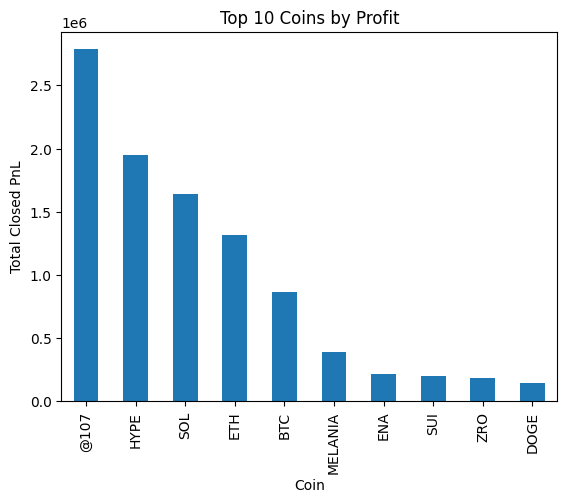

In [49]:
# Chart

top_coins.head(10).plot(kind='bar')

plt.title("Top 10 Coins by Profit")
plt.ylabel("Total Closed PnL")
plt.show()

In [50]:
# Buy vs Sell Behavior

pd.crosstab(df['classification'], df['Side'])

Side,BUY,SELL
classification,,
Extreme Fear,10935,10465
Extreme Greed,17940,22052
Fear,30270,31567
Greed,24576,25727
Neutral,18969,18717


In [51]:
profit_by_sentiment = df.groupby('classification')['Closed PnL'].mean()
print(profit_by_sentiment)

win_rate = df.groupby('classification')['Win'].mean() * 100
print(win_rate)

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64
classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: Win, dtype: float64


In [52]:
# Trading Volume by Sentiment

volume = df.groupby('classification')['Size USD'].sum()
print(volume)

classification
Extreme Fear     1.144843e+08
Extreme Greed    1.244652e+08
Fear             4.833248e+08
Greed            2.885825e+08
Neutral          1.802421e+08
Name: Size USD, dtype: float64


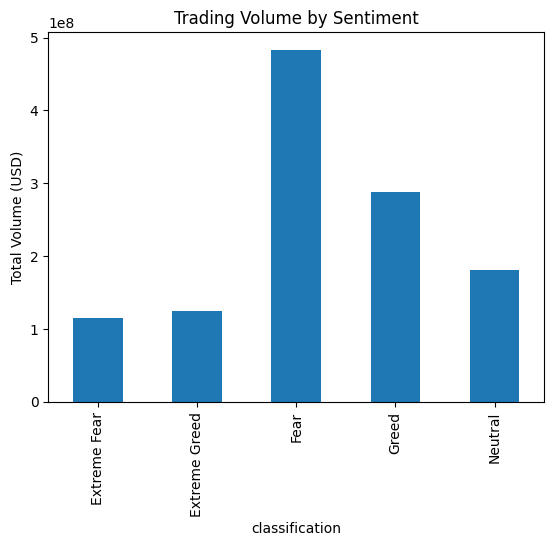

In [63]:
# Chart

volume.plot(kind='bar')
plt.title('Trading Volume by Sentiment')
plt.ylabel('Total Volume (USD)')
plt.savefig("Trading Volume by Sentiment", bbox_inches="tight")
plt.show()

In [55]:
# Top 10 Coins by Profit

top_coins = df.groupby('Coin')['Closed PnL'].sum().sort_values(ascending=False)
print(top_coins.head(10))

Coin
@107       2.783913e+06
HYPE       1.948485e+06
SOL        1.639556e+06
ETH        1.319979e+06
BTC        8.680447e+05
MELANIA    3.903511e+05
ENA        2.173295e+05
SUI        1.992688e+05
ZRO        1.837778e+05
DOGE       1.475432e+05
Name: Closed PnL, dtype: float64


In [56]:
# Most Traded Coins

most_traded = df['Coin'].value_counts().head(10)
print(most_traded)

Coin
HYPE         68005
@107         29992
BTC          26064
ETH          11158
SOL          10691
FARTCOIN      4650
MELANIA       4428
PURR/USDC     2774
WLD           1983
SUI           1979
Name: count, dtype: int64


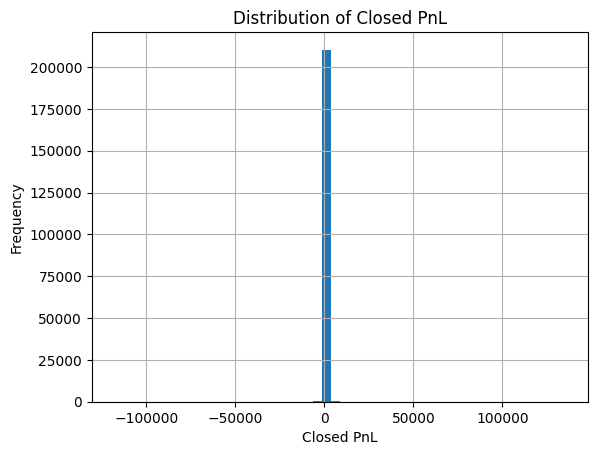

In [64]:
# Profit Distribution

df['Closed PnL'].hist(bins=50)
plt.title('Distribution of Closed PnL')
plt.xlabel('Closed PnL')
plt.ylabel('Frequency')
plt.savefig("Distribution of Closed PnL", bbox_inches="tight")
plt.show()

## Conclusion

The analysis demonstrates that trader performance improves during optimistic market conditions, particularly Extreme Greed periods. Traders achieved higher profitability and win rates during these periods, while Extreme Fear conditions corresponded to lower success rates.

In [65]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'app.py', 'Clustering_Project.ipynb', 'Clustering_README.md', 'Customer_churn.ipynb', 'customer_churn_500x7.csv', 'Distribution of Closed PnL.png', 'fear_greed_index.csv', 'Flights_Project.ipynb', 'Flights_README.md', 'historical_data.csv', 'Iris_project.ipynb', 'Iris_README.md', 'Netfilx_Data_Analysis.ipynb', 'netflix_dataset.csv', 'Number of Trades by Sentiment.png', 'Penguin_Project.ipynb', 'profit_by_sentiment.png', 'README (1).md', 'requirements.txt', 'Tips_Project.ipynb', 'Tips_README.md', 'titanic_model.pkl', 'Titanic_Project.ipynb', 'Titanic_README.md', 'Trading Volume by Sentiment.png', 'Untitled.ipynb', 'Win Rate by Sentiment.png']


In [66]:
volume = df.groupby('classification')['Size USD'].sum()
print(volume)

classification
Extreme Fear     1.144843e+08
Extreme Greed    1.244652e+08
Fear             4.833248e+08
Greed            2.885825e+08
Neutral          1.802421e+08
Name: Size USD, dtype: float64
